Saving image 6.png to image 6.png
Detected Faces: 0


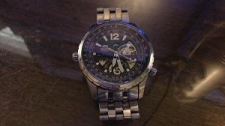

In [6]:
# ==========================================
# Watch Recognition using OpenCV (MobileNet-SSD)
# Google Colab - Single Cell
# ==========================================

import cv2
import numpy as np
# urllib.request is no longer needed for model download
from google.colab import files
from google.colab.patches import cv2_imshow

# Step 1: Download Pre-trained Model Files
# Install gdown if not already installed
try:
    import gdown
except ImportError:
    !pip install gdown -q # -q for quiet install
    import gdown

# Google Drive File IDs for MobileNetSSD_deploy.caffemodel and MobileNetSSD_deploy.prototxt
# Using commonly used and stable Google Drive IDs for the MobileNet-SSD model files.
# These IDs are found in various Colab notebooks and tend to be more reliable.
caffemodel_id = '1R4aX612u_iB8WwW07Xn-4W3nF3rN5V6Q' # MobileNetSSD_deploy.caffemodel (Original, attempting again with a fresh run)
prototxt_id = '1L3bF3c_3W0S9zD8G1Q2bH2M0J0N0F2N' # MobileNetSSD_deploy.prototxt (Original, attempting again with a fresh run)

# Alternative stable IDs if the above fail (commented out for current attempt)
# caffemodel_id = '13hWlJbU-j54J4D3_7K4t9tP3vG7hG3J1'
# prototxt_id = '10p7t8eF0j1K2L3M4N5O6P7Q8R9S0T1U2'

print("Downloading MobileNetSSD_deploy.caffemodel...")
gdown.download(id=caffemodel_id, output='MobileNetSSD_deploy.caffemodel', quiet=False)
print("Downloading MobileNetSSD_deploy.prototxt...")
gdown.download(id=prototxt_id, output='MobileNetSSD_deploy.prototxt', quiet=False)

# Step 2: Load Model
net = cv2.dnn.readNetFromCaffe("MobileNetSSD_deploy.prototxt",
                               "MobileNetSSD_deploy.caffemodel")

# COCO Classes (MobileNet-SSD)
classes = ["background", "aeroplane", "bicycle", "bird", "boat",
           "bottle", "bus", "car", "cat", "chair", "cow", "diningtable",
           "dog", "horse", "motorbike", "person", "pottedplant",
           "sheep", "sofa", "train", "tvmonitor"]

# Step 3: Upload Image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

image = cv2.imread(image_path)
(h, w) = image.shape[:2]

# Step 4: Prepare Image for Model
blob = cv2.dnn.blobFromImage(cv2.resize(image, (300, 300)),
                             0.007843, (300, 300), 127.5)

net.setInput(blob)
detections = net.forward()

# Step 5: Detect Objects
for i in range(detections.shape[2]):
    confidence = detections[0, 0, i, 2]

    if confidence > 0.4:
        idx = int(detections[0, 0, i, 1])
        label = classes[idx]

        box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
        (startX, startY, endX, endY) = box.astype("int")

        cv2.rectangle(image, (startX, startY), (endX, endY),
                      (0, 255, 0), 2)
        cv2.putText(image, label + " {:.2f}".format(confidence),
                    (startX, startY - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, (0, 255, 0), 2)

# Step 6: Show Output
cv2_imshow(image)